In [1]:
import random
random.seed(42)
nodes = {
    0: (0, 0), 1: (2, 5), 2: (8, 3), 3: (5, 9), 4: (1, 7),
    5: (6, 4), 6: (9, 9), 7: (3, 1), 8: (7, 8), 9: (4, 4)
}

N = list(nodes.keys())
Q = 7
Depot = 0
C = [i for i in nodes.keys() if i != Depot]
K = range(3)
q = {i: random.randint(1,5) for i in C}

t = {(i,j) :random.randint(1,60) for i in N for j in N if j != i}

start_time = 0
end_time = 540

twindow = {
 0: (start_time,   end_time),   # 09:00 AM - 06:00 PM  (depot)
 1: (120, 300),   # 11:00 AM - 02:00 PM
 2: (45,  180),   # 09:45 AM - 12:00 PM
 3: (400, 540),   # 03:40 PM - 06:00 PM
 4: (200, 260),   # 12:20 PM - 01:20 PM
 5: (0,   90),    # 09:00 AM - 10:30 AM
 6: (330, 480),   # 02:30 PM - 05:00 PM
 7: (250, 400),   # 01:10 PM - 03:40 PM
 8: (60,  200),   # 10:00 AM - 12:20 PM
 9: (480, 540),   # 05:00 PM - 06:00 PM
}


s = {
    0: 0,    # depot — no service
    1: 10,
    2: 15,
    3: 5,
    4: 20,
    5: 8,
    6: 12,
    7: 6,
    8: 18,
    9: 9,
}

In [2]:
import math
distance = {}
for i in (N):
    for j in (N):
        if i == j:
            distance[i,j] = 0
        else:
            xi,yi = nodes[i]
            xj,yj = nodes[j]
            dx, dy = xi-xj , yi-yj
            distance[i,j] = math.hypot(dx,dy)

In [3]:
from ortools.sat.python import cp_model

In [4]:
model = cp_model.CpModel()

In [5]:
z = {(i, k): model.NewBoolVar(f"z[{i,k}]") for i in C for k in K} 
y = {k: model.NewBoolVar(f"y[{k}]") for k in K} 
w = {(i,k): model.NewIntVar(twindow[i][0], twindow[i][1],f"w[{i,k}]") for i in C for k in K}

In [6]:
start_car = {k: model.NewIntVar(start_time, end_time, f"start[{k}]") for k in K}
end_car = {k: model.NewIntVar(start_time, end_time, f"end[{k}]") for k in K}

# for k in K:
#     model.Add(start_car[k] == 0).OnlyEnforceIf(y[k].Not())
#     model.Add(end_car[k] == 0).OnlyEnforceIf(y[k].Not())

In [7]:
x = {}
for k in K:
    arcs = []
    for i in N:
        for j in N:
            if i!=j:
                x[i,j,k] = model.NewBoolVar(f"x[{i},{j},{k}]")
                arcs.append((i,j,x[i,j,k]))
            else:
                if i == Depot:
                    x[Depot,Depot,k] = y[k].Not()
                    arcs.append((Depot,Depot,x[Depot,Depot,k]))

                    
                else:# i != 0:
                    x[i,i,k] = z[i,k].Not()
                    arcs.append((i,i,x[i,i,k]))
    model.AddCircuit(arcs)
                    

In [8]:
for i in C:
    model.AddExactlyOne(z[i,k] for k in K) # visit once

for k in K:
    model.Add(sum(q[i]*z[i,k] for i in C) <= Q*y[k]) #capacity 

In [9]:
for k in K:
    for i in C:
        for j in C:
            if i != j:
                # customer to customer 
                model.Add(w[i,k] + s[i] + t[i,j] <= w[j,k]).OnlyEnforceIf(x[i,j,k])
                
        model.Add(start_car[k] + s[0] + t[0,i] <= w[i,k]).OnlyEnforceIf(x[0,i,k]) # depot to customer
        model.Add(w[i,k] + s[i] + t[i,0] <= end_car[k]).OnlyEnforceIf(x[i,0,k]) # customer to depot
                

In [13]:
model.Minimize(
    100*sum(
        distance[i,j]*x[i,j,k]
        for i in N
        for j in N
        for k in K
        if i != j
    ) + 
    sum(end_car[k] - start_car[k] for k in K)
)

In [14]:
solver = cp_model.CpSolver()
status = solver.solve(model)
status

<CpSolverStatus.OPTIMAL: 4>

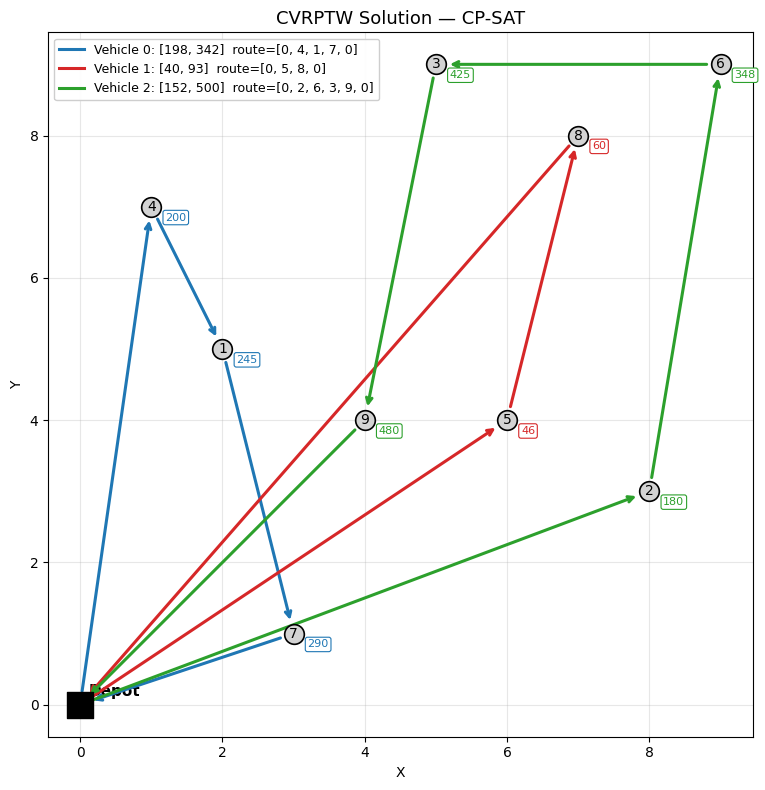

Objective (total distance): 7338.95

Vehicle 0:
  Start: 198  End: 342
  → Cust 4: arrive=200, tw=(200, 260), demand=2
  → Cust 1: arrive=245, tw=(120, 300), demand=1
  → Cust 7: arrive=290, tw=(250, 400), demand=1
  Route: 0 → 4 → 1 → 7 → 0

Vehicle 1:
  Start: 40  End: 93
  → Cust 5: arrive=46, tw=(0, 90), demand=2
  → Cust 8: arrive=60, tw=(60, 200), demand=5
  Route: 0 → 5 → 8 → 0

Vehicle 2:
  Start: 152  End: 500
  → Cust 2: arrive=180, tw=(45, 180), demand=1
  → Cust 6: arrive=348, tw=(330, 480), demand=2
  → Cust 3: arrive=425, tw=(400, 540), demand=3
  → Cust 9: arrive=480, tw=(480, 540), demand=1
  Route: 0 → 2 → 6 → 3 → 9 → 0



In [15]:
# Directly copy-pasted this part from AI
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize(solver, x, y, z, w, start_car, end_car, nodes, C, K, depot=0):
    fig, ax = plt.subplots(figsize=(11, 8))
    colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:orange', 'tab:purple']

    # Depot
    ax.scatter(*nodes[depot], c='black', s=350, marker='s', zorder=5)
    ax.annotate('Depot', nodes[depot], fontsize=11, fontweight='bold',
                xytext=(6, 6), textcoords='offset points')

    # Customers
    for i in C:
        ax.scatter(*nodes[i], c='lightgray', s=200, zorder=4,
                   edgecolors='black', linewidths=1.2)
        ax.annotate(f'{i}', nodes[i], fontsize=10, ha='center', va='center', zorder=6)

    # Extract and draw routes
    for k in K:
        if solver.Value(y[k]) == 0:
            continue
        color = colors[k % len(colors)]

        # walk the route
        route = [depot]
        cur = depot
        while True:
            nxt = None
            for j in nodes:
                if j != cur and solver.Value(x[cur, j, k]) == 1:
                    nxt = j
                    break
            if nxt is None or nxt == depot:
                route.append(depot)
                break
            route.append(nxt)
            cur = nxt

        # arrows
        for a, b in zip(route[:-1], route[1:]):
            ax.annotate('', xy=nodes[b], xytext=nodes[a],
                        arrowprops=dict(arrowstyle='->', color=color,
                                        lw=2.2, shrinkA=10, shrinkB=10),
                        zorder=3)

        # arrival time labels
        for i in route[1:-1]:
            t_arr = solver.Value(w[i, k])
            ax.annotate(f'{t_arr}', nodes[i], fontsize=8, color=color,
                        xytext=(10, -10), textcoords='offset points',
                        bbox=dict(boxstyle='round,pad=0.2', fc='white',
                                  ec=color, lw=0.8), zorder=7)

        # legend entry
        s_t = solver.Value(start_car[k])
        e_t = solver.Value(end_car[k])
        ax.plot([], [], color=color, lw=2.2,
                label=f'Vehicle {k}: [{s_t}, {e_t}]  route={route}')

    ax.legend(loc='upper left', fontsize=9, framealpha=0.95)
    ax.set_title('CVRPTW Solution — CP-SAT', fontsize=13)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()


def print_schedule(solver, x, y, z, w, start_car, end_car, nodes, C, K, depot=0):
    print(f"Objective (total distance): {solver.ObjectiveValue():.2f}\n")
    for k in K:
        used = solver.Value(y[k])
        if used == 0:
            print(f"Vehicle {k}: UNUSED")
            continue

        # reconstruct route
        route = [depot]
        cur = depot
        while True:
            nxt = None
            for j in nodes:
                if j != cur and solver.Value(x[cur, j, k]) == 1:
                    nxt = j
                    break
            if nxt is None or nxt == depot:
                route.append(depot)
                break
            route.append(nxt)
            cur = nxt

        print(f"Vehicle {k}:")
        print(f"  Start: {solver.Value(start_car[k])}  End: {solver.Value(end_car[k])}")
        for i in route:
            if i == depot:
                continue
            print(f"  → Cust {i}: arrive={solver.Value(w[i,k])}, "
                  f"tw={twindow[i]}, demand={q[i]}")
        print(f"  Route: {' → '.join(map(str, route))}\n")


# ---------------- run ----------------
visualize(solver, x, y, z, w, start_car, end_car, nodes, C, K, depot=0)
print_schedule(solver, x, y, z, w, start_car, end_car, nodes, C, K, depot=0)